### Técnicas de imputación ***Univariada***

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def graficar_serie(df, obs = '', titulo=''):
    '''
    Graficar la serie y ver sus valores extremos
    Params:
        - df    : DataFrame de Pandas con la serie de tiempo
        - obs   : Nombre de la columna a graficar
        - titulo: Título del gráfico
    '''

    fig, ax = plt.subplots(1, 1)

    if type(df) == pd.DataFrame:
        ax = sns.pointplot(data = df, x = df.index, y = obs, markers='')
    else:
        df = df.to_frame(name = obs)
        ax = sns.pointplot(data = df, x = df.index, y = obs, markers='')
    
    n_ticks = 10
    locator = mdates.AutoDateLocator(maxticks = n_ticks)
    ax.xaxis.set_major_locator(locator)

    plt.xticks(rotation = 45)
    
    ax.set_xlabel('Tiempo')
    ax.set_ylabel(obs)
    ax.set_title(titulo)     

### Imputación ***Univariada*** usando pandas

* Realizar imputación por la media
* Realizar imputación por llenado hacia adelante ***ffill***
* Realizar imputación por llenado hacia atrás ***bfill***

#### Imputación por la media

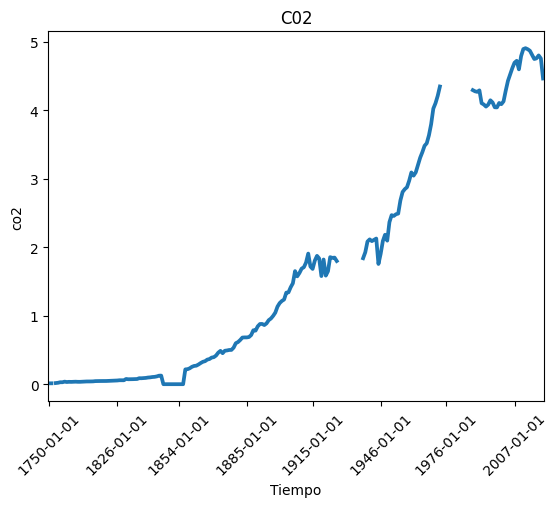

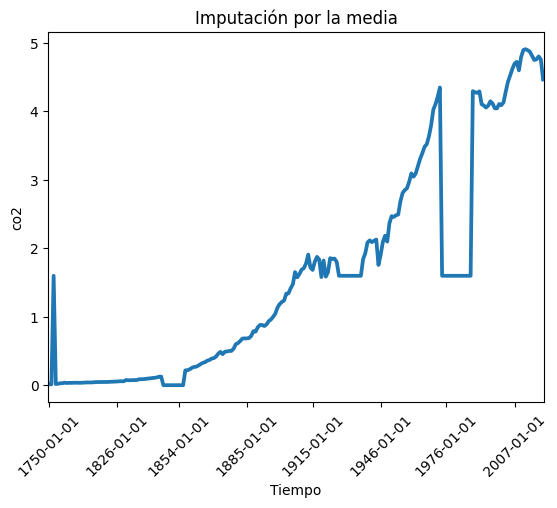

In [2]:
co2 = pd.read_csv('datos/co2_faltantes.csv',
                    parse_dates = ['año'], 
                    index_col = 'año')
graficar_serie(co2, obs = 'co2', titulo = 'C02')

co2_imp = co2['co2'].fillna(co2['co2'].mean())
graficar_serie(co2_imp, obs = 'co2', titulo = 'Imputación por la media')

/tmp/ipykernel_137295/474641920.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clicks = pd.read_csv('datos/clicks_obs_faltantes.csv',


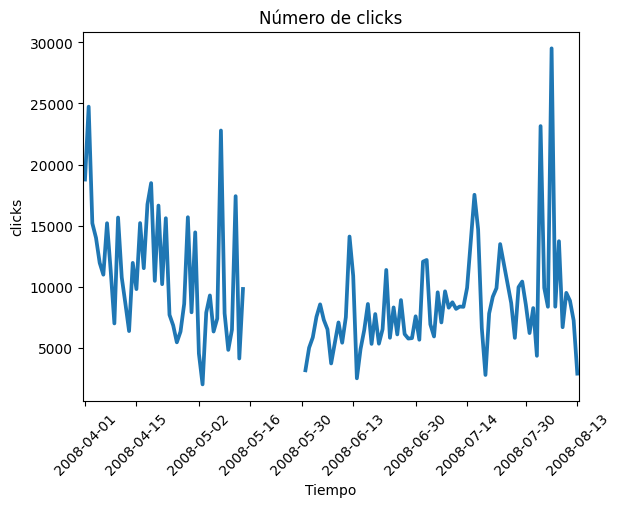

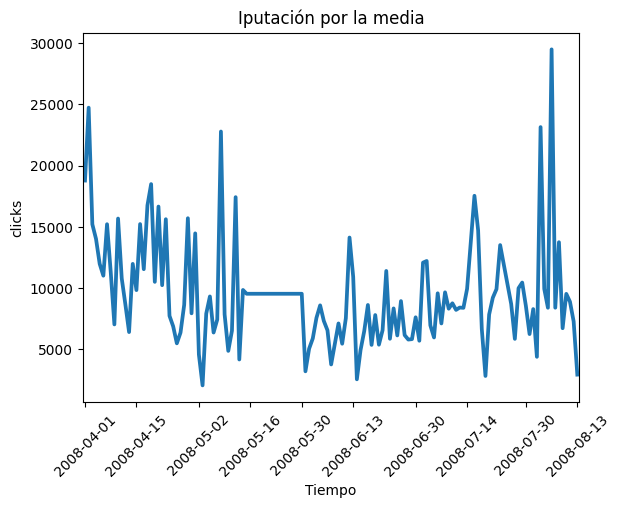

In [3]:
clicks = pd.read_csv('datos/clicks_obs_faltantes.csv',
                    parse_dates = ['fecha'], 
                    index_col = 'fecha')
graficar_serie(clicks, obs = 'clicks', titulo = 'Número de clicks')

clicks_imp = clicks['clicks'].fillna(clicks['clicks'].mean())
graficar_serie(clicks_imp, obs = 'clicks', titulo = 'Iputación por la media')

#### Imputación por llenado hacia adelante ***ffill***

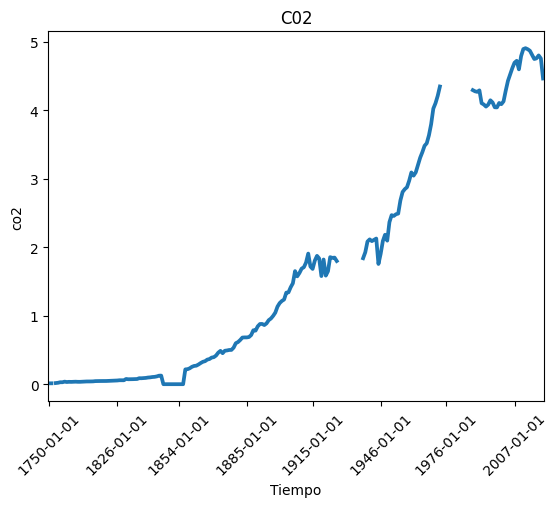

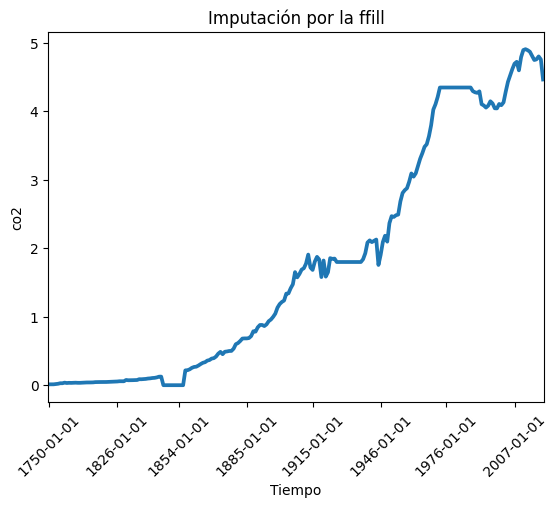

In [4]:
graficar_serie(co2, obs = 'co2', titulo = 'C02')

co2_ffill = co2['co2'].ffill()
graficar_serie(co2_ffill, obs = 'co2', titulo = 'Imputación por la ffill')

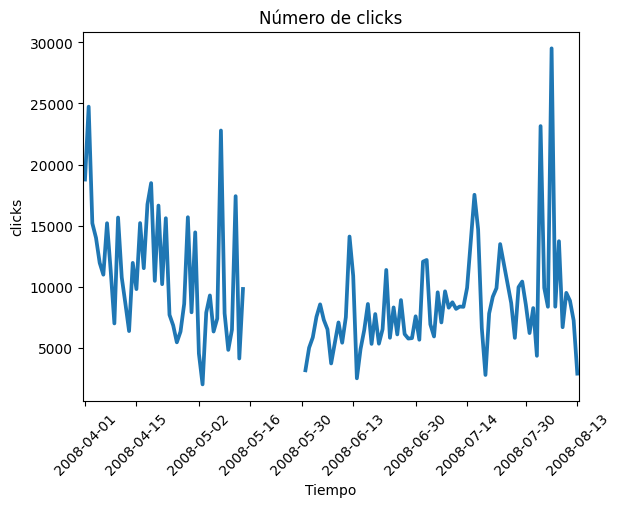

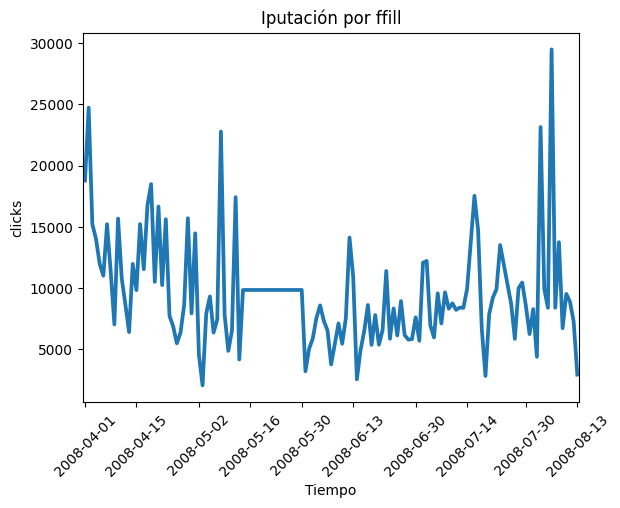

In [5]:
graficar_serie(clicks, obs = 'clicks', titulo = 'Número de clicks')

clicks_imp = clicks['clicks'].ffill()
graficar_serie(clicks_imp, obs = 'clicks', titulo = 'Iputación por ffill')

#### Imputación por llenado hacia adelante ***bfill***

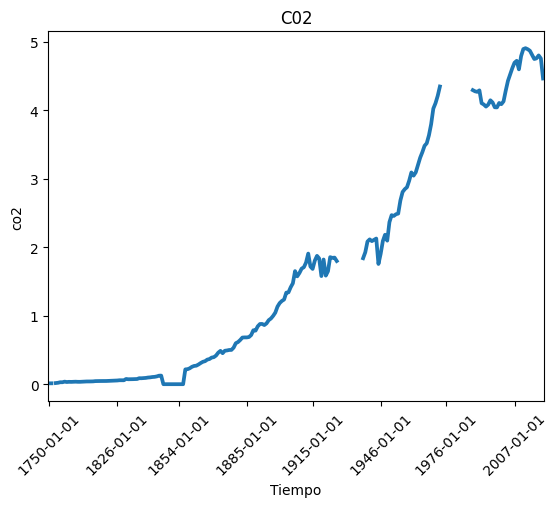

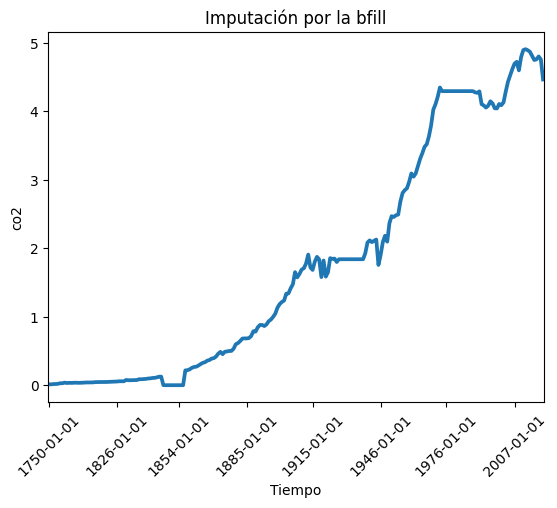

In [6]:
graficar_serie(co2, obs = 'co2', titulo = 'C02')

co2_ffill = co2['co2'].bfill()
graficar_serie(co2_ffill, obs = 'co2', titulo = 'Imputación por la bfill')

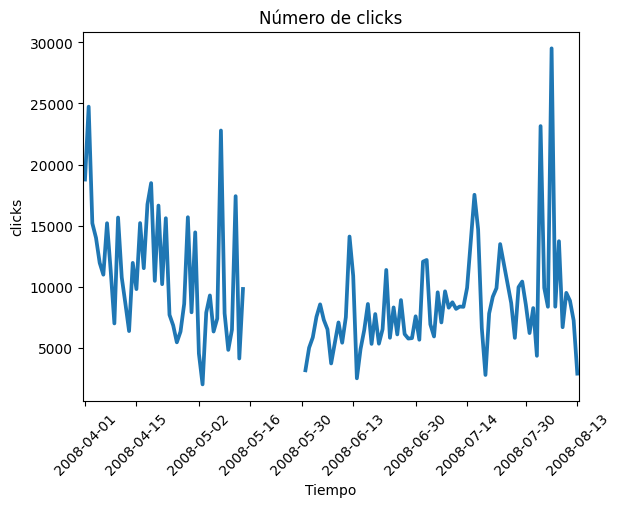

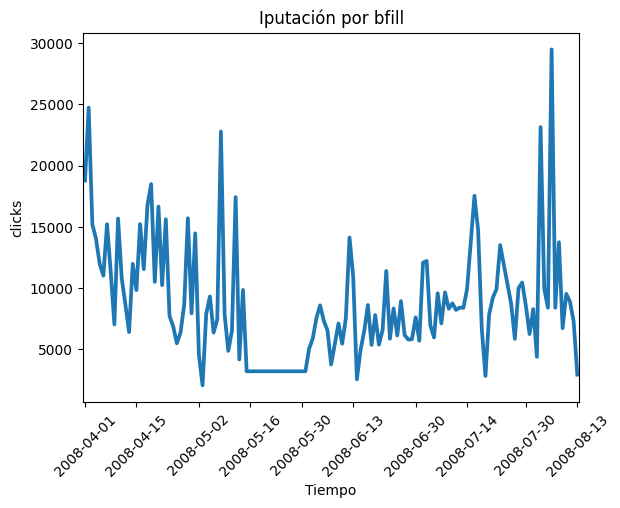

In [7]:
graficar_serie(clicks, obs = 'clicks', titulo = 'Número de clicks')

clicks_imp = clicks['clicks'].bfill()
graficar_serie(clicks_imp, obs = 'clicks', titulo = 'Iputación por bfill')

### Imputación ***Univariada*** usando Sklearn

- Media
- Mediana
- Valor más frecuente

In [8]:
from sklearn.impute import SimpleImputer

estrategias = [
    ('imp_media', 'mean'),
    ('imp_mediana', 'median'),
    ('imp_frec', 'most_frequent')]

co2_vals = co2['co2'].to_numpy().reshape(-1,1)

for nombre, estrategia in estrategias:
    co2[nombre] = SimpleImputer(strategy = estrategia).fit_transform(co2_vals)

co2.head()


,co2,imp_media,imp_mediana,imp_frec
año,,,,
1750-01-01,0.0125,0.01250,0.01250,0.0125
1760-01-01,0.0128,0.01280,0.01280,0.0128
1770-01-01,NaN,1.59789,0.94705,0.0000
1780-01-01,0.0169,0.01690,0.01690,0.0169
1790-01-01,0.0206,0.02060,0.02060,0.0206


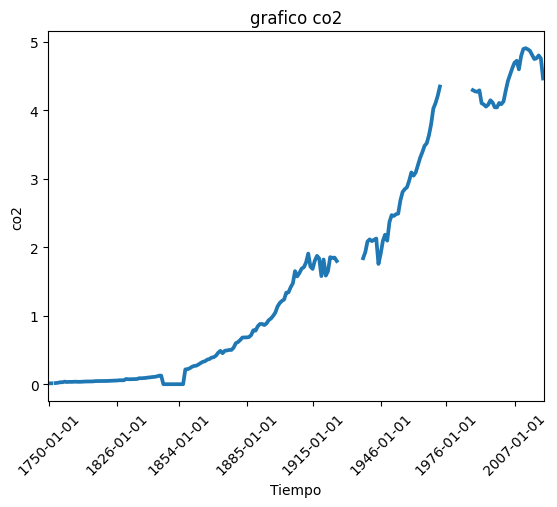

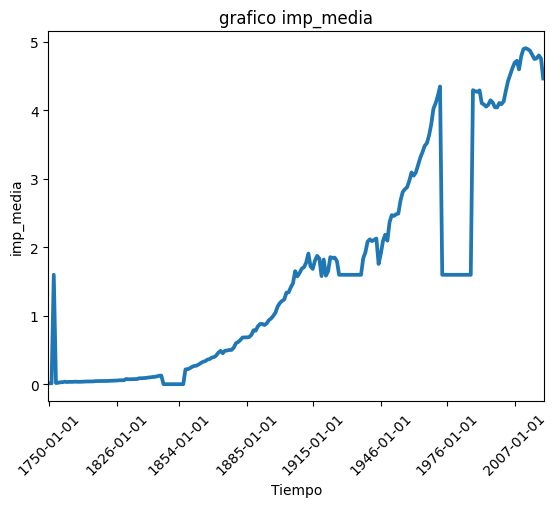

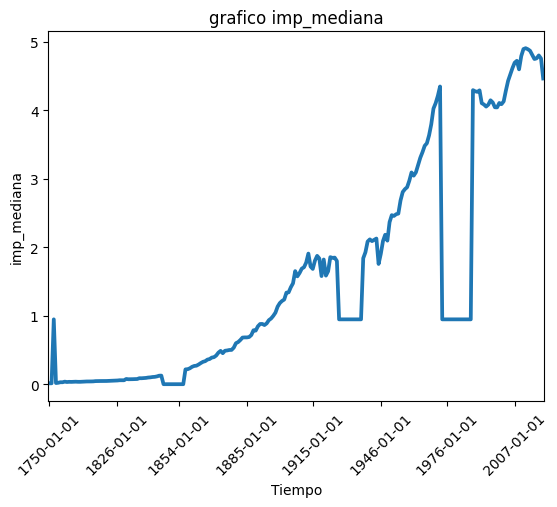

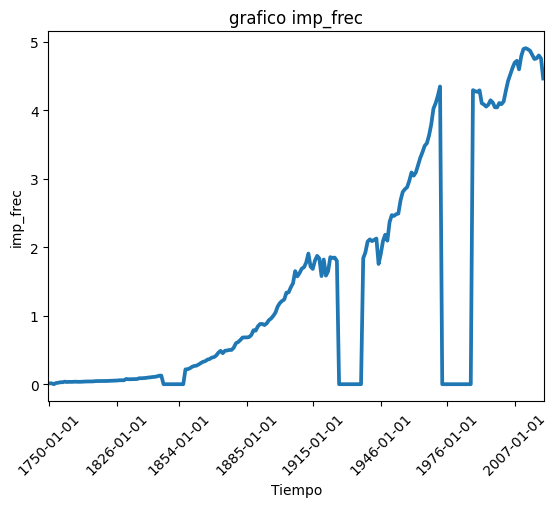

In [23]:
for col in co2.columns:
    graficar_serie(co2, obs = col, titulo = f'grafico {col}')

In [25]:
clicks_vals = clicks['clicks'].to_numpy().reshape(-1,1)

for nombre, estrategia in estrategias:
    clicks[nombre] = SimpleImputer(strategy = estrategia).fit_transform(clicks_vals)
clicks.drop(columns=['precio', 'ubicación'], inplace=True)
clicks.head()

,clicks,imp_media,imp_mediana,imp_frec
fecha,,,,
2008-04-01,18784.0,18784.0,18784.0,18784.0
2008-04-02,24738.0,24738.0,24738.0,24738.0
2008-04-03,15209.0,15209.0,15209.0,15209.0
2008-04-04,14018.0,14018.0,14018.0,14018.0
2008-04-05,11974.0,11974.0,11974.0,11974.0


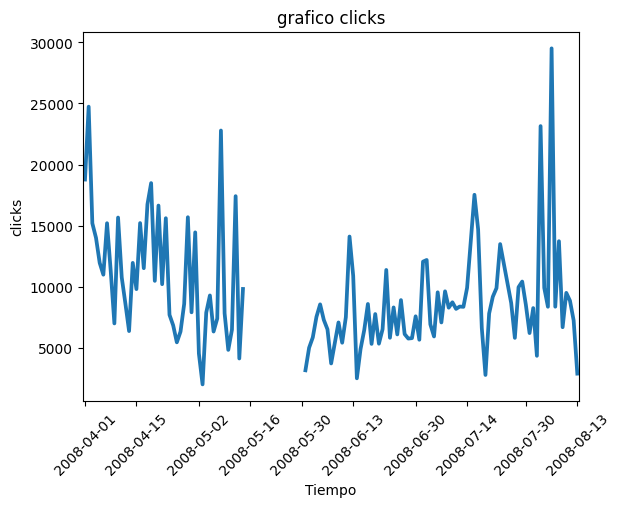

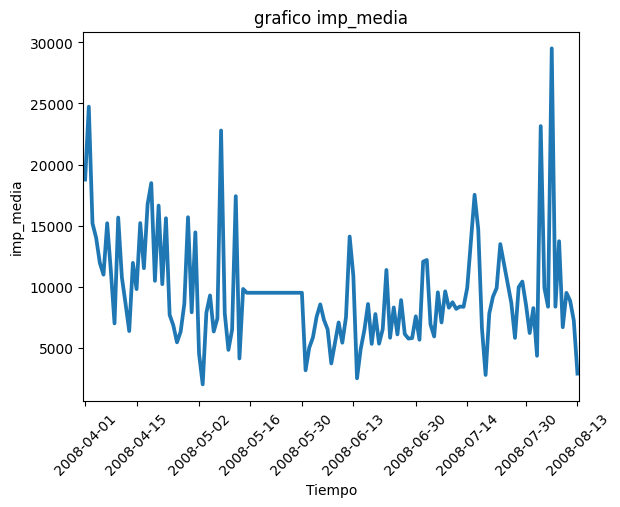

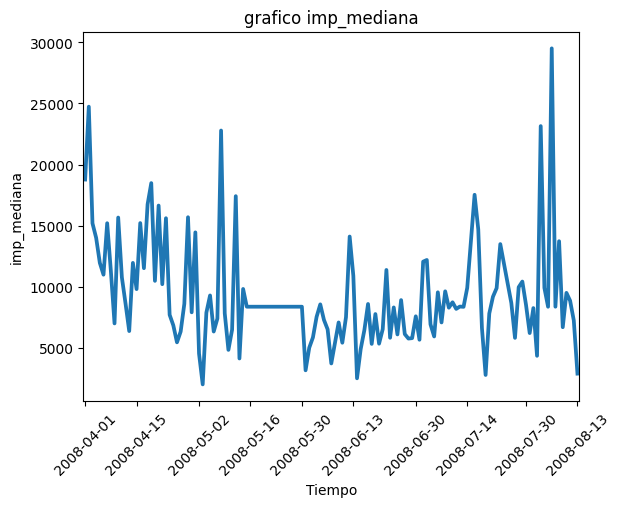

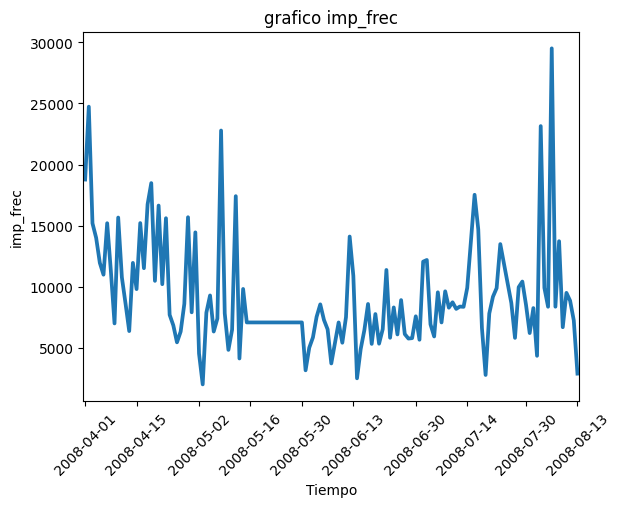

In [26]:
for col in clicks.columns:
    graficar_serie(clicks, obs = col, titulo = f'grafico {col}')